<a href="https://colab.research.google.com/github/alexyh1/STA4000/blob/main/code/chapter2_kantorovich/2.1_Exact_OT_Discrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 17.9 MB/s eta 0:00:00


In [44]:
import numpy as np
import matplotlib.pyplot as plt
import ot
from ot.datasets import make_1D_gauss as gauss
from ot.plot import plot2D_samples_mat
import time


np.random.seed(4000)

n1_1 = 10
n2_1 = 10

a_1 = np.ones(n1_1) / n1_1
b_1 = np.ones(n2_1) / n2_1

x1_1 = 0.5*np.random.randn(n1_1, 2)
x2_1 = 0.5*np.random.randn(n2_1, 2)

sol_1 = ot.solve_sample(x1_1, x2_1, a_1, b_1)

P_1 = sol_1.plan
loss_1 = sol_1.value

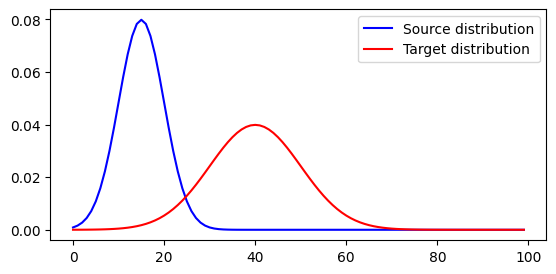

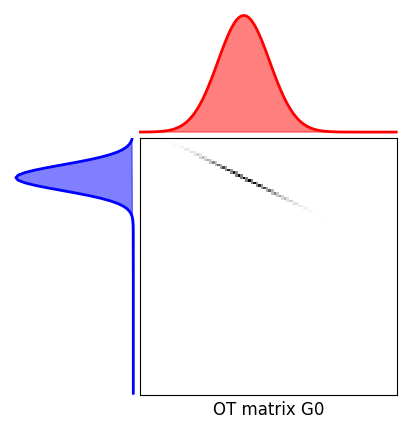

In [51]:
n1_2 = 100
n2_2 = 100

x_2 = np.arange(n1_2, dtype=np.float64)

a_2 = gauss(n1_2, m=15, s=5)
b_2 = gauss(n2_2, m=40, s=10)

M = ot.dist(x_2.reshape((n1_2, 1)), x_2.reshape((n2_2, 1)))
M /= M.max()

plt.figure(0, figsize=(6.4, 3))
plt.plot(x_2, a_2, "b", label="Source distribution")
plt.plot(x_2, b_2, "r", label="Target distribution")
plt.legend()
plt.show()

G0 = ot.emd_1d(x_2, x_2, a_2, b_2)

plt.figure(1, figsize=(5, 5))
ot.plot.plot1D_mat(a_2, b_2, G0, "OT matrix G0")
plt.show()

In [42]:
n1_3 = 20
n2_3 = 30
a_3 = np.random.rand(n1_3)
a_3 = a_3 / sum(a_3)
b_3 = np.random.rand(n2_3)
b_3 = b_3 / sum(b_3)

x1_3 = np.random.randn(n1_3, 2)
x2_3 = np.random.randn(n2_3, 2)

sol_3 = ot.solve_sample(x1_3, x2_3, a_3, b_3)

P_3 = sol_3.plan
loss_3 = sol_3.value

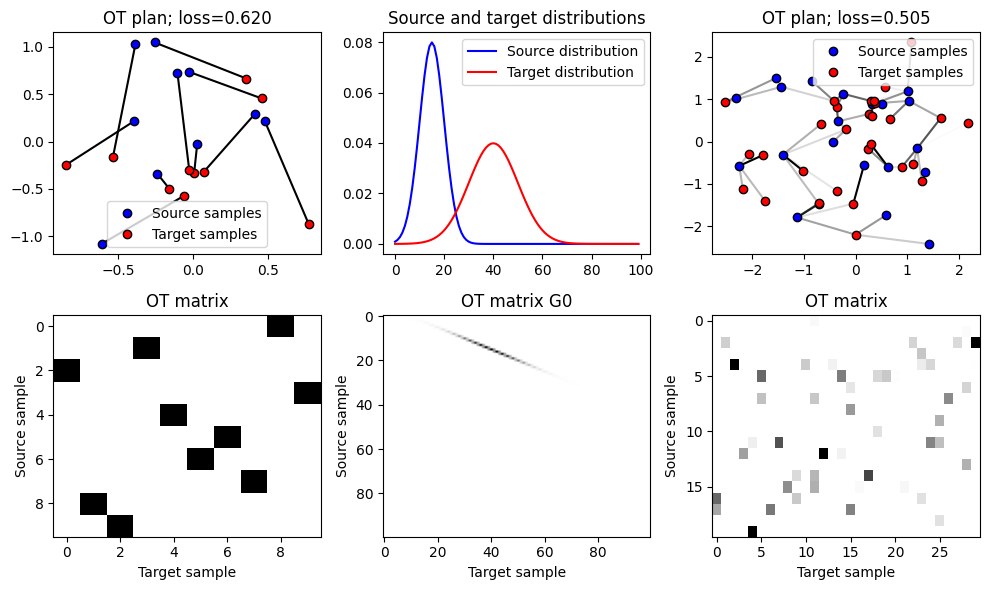

In [59]:
style = {"markeredgecolor": "k"}
def plot_plan(i, title="", axis=True):
    x1_i = globals()[f"x1_{i}"]
    x2_i = globals()[f"x2_{i}"]
    P_i = globals()[f"P_{i}"]
    if P_i is not None:
        plot2D_samples_mat(x1_i, x2_i, P_i)

    plt.plot(x1_i[:, 0], x1_i[:, 1], "ob",
             label="Source samples", **style)
    plt.plot(x2_i[:, 0], x2_i[:, 1], "or",
             label="Target samples", **style)

    if not axis:
        plt.axis("off")
    plt.title(title)


plt.figure(figsize=(10, 6))

plt.subplot(2, 3, 1)
plot_plan(1, f"OT plan; loss={loss_1:.3f}")
plt.legend(loc=0)

plt.subplot(2, 3, 4)
plt.imshow(P_1, cmap="Greys", aspect="auto")
plt.title("OT matrix")
plt.xlabel("Target sample")
plt.ylabel("Source sample")

plt.subplot(2, 3, 2)
plt.plot(x_2, a_2, "b", label="Source distribution")
plt.plot(x_2, b_2, "r", label="Target distribution")
plt.title("Source and target distributions")
plt.legend()

plt.subplot(2, 3, 5)
plt.imshow(G0, cmap="Greys", aspect="auto")
plt.title("OT matrix G0")
plt.xlabel("Target sample")
plt.ylabel("Source sample")

plt.subplot(2, 3, 3)
plot_plan(3, f"OT plan; loss={loss_3:.3f}")
plt.legend(loc=0)

plt.subplot(2, 3, 6)
plt.imshow(P_3, cmap="Greys", aspect="auto")
plt.title("OT matrix")
plt.xlabel("Target sample")
plt.ylabel("Source sample")

plt.tight_layout()
plt.show()

